In [1]:
from zomba.singleObjective.simulator import SLBSimulator
from zomba.singleObjective.stochastic import SLBUCB

In [2]:
K = 10
d = 10

env = SLBSimulator(num_arm=K, num_dim=d, vary_context=1)

In [3]:
env.reset(verbose=1)

# dimension: 10
# arms: 10
Optimal arm: 6
Regret for each arm: [0.3432, 0.3298, 0.0734, 0.4674, 0.3488, 0.4754, 0.0, 0.1556, 0.2201, 0.5698]


In [4]:
alg = SLBUCB(num_arm=K, num_dim=d, rarely_switch=1) 

In [5]:
alg.reset()

In [6]:
env.observe_context()

array([[ 2.36214474e-01,  1.26247473e-01, -5.41742273e-01,
        -2.53241224e-01,  7.64468638e-02,  2.87151779e-01,
        -4.50796989e-01, -4.48261404e-01, -2.60787002e-01,
        -1.05755495e-03],
       [-6.89902054e-02, -3.83117276e-01,  2.23827895e-01,
        -3.46062066e-01, -5.03381580e-01,  1.44025428e-02,
         1.43067742e-01, -1.59649749e-01, -3.62872750e-01,
        -4.76029568e-01],
       [-4.02980275e-01,  1.05672504e-01, -2.02962464e-01,
         2.34348893e-01,  2.28752439e-01,  3.06365914e-01,
         9.35923207e-02,  9.39259719e-02, -3.60675072e-01,
        -1.08512547e-01],
       [ 1.01988370e-01,  3.74858629e-01, -2.08346449e-02,
        -4.49627207e-01,  2.07188864e-01,  9.05289060e-02,
        -6.89975842e-02, -4.43879203e-01, -3.23394634e-01,
        -1.41584120e-01],
       [-2.95150502e-01, -2.51528384e-01, -2.64501314e-01,
         7.28018835e-02, -4.99689107e-01,  1.19938813e-01,
        -7.09542928e-02, -6.77354141e-01,  4.23942619e-02,
         2.

In [7]:
a_t = alg.take_action(context=env.observe_context())

In [8]:
env.get_reward(a_t)

0.8138865201613961

In [9]:
env.get_regret(a_t)

0.0

In [10]:
T = int(1e4)
alg.reset()
env.reset()
reg = [0]
cum_reg = 0
for t in range(T): 
    X = env.observe_context() 
    a_t = alg.take_action(X, alpha=1) 
    r = env.get_reward(arm=a_t) 
    cum_reg += env.get_regret(arm=a_t) 
    reg.append(cum_reg)
    alg.update(action=a_t, reward=r, context=X)
    if (t+1) % 100 == 0: 
        print(f"round: {t+1}, cumulative regret: {cum_reg}")
    

round: 100, cumulative regret: 19.42460086970776
round: 200, cumulative regret: 27.916405128479937
round: 300, cumulative regret: 33.04009626469475
round: 400, cumulative regret: 39.01864385964131
round: 500, cumulative regret: 43.03713198360193
round: 600, cumulative regret: 45.88227901129143
round: 700, cumulative regret: 48.54734871776489
round: 800, cumulative regret: 51.92739270076362
round: 900, cumulative regret: 53.94355212660681
round: 1000, cumulative regret: 56.6259499822989
round: 1100, cumulative regret: 58.63218751936141
round: 1200, cumulative regret: 61.13256502547132
round: 1300, cumulative regret: 63.15163232865285
round: 1400, cumulative regret: 64.91074651189557
round: 1500, cumulative regret: 65.98375494174974
round: 1600, cumulative regret: 67.69226201717983
round: 1700, cumulative regret: 69.38049152571239
round: 1800, cumulative regret: 71.10366009024423
round: 1900, cumulative regret: 72.42552190824645
round: 2000, cumulative regret: 73.69893177646713
round: 21

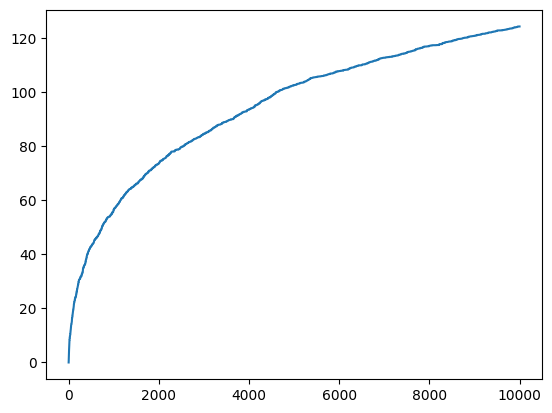

In [11]:
import matplotlib.pyplot as plt 

plt.plot(range(T+1), reg)
plt.show()